# 📊 CRUZBER S&OP: Resumen Ejecutivo y Evaluación Crítica (Iteraciones 21-23)

Bienvenidos a la consolidación de la primera gran fase predictiva del proyecto. Este cuaderno sirve como punto de control corporativo.

Aquí vamos a diseccionar, con visión de negocio y sin ruido algorítmico excesivo, **cómo hemos salvado la brecha entre una base de datos ciega y un sistema logístico proactivo capaz de predecir la demanda de Cruzber a 3 meses vista.**

---

## 🧭 1. El Viaje: De la "Miopía Cronológica" al Modelo Madúro

Para que una IA entienda cómo comprar recambios, no basta con pasarle facturas. Tuvimos que enseñarle cómo pasa el tiempo. En estas tres iteraciones hemos escalado el sistema capa por capa:

1. **Iteración 21 (Demolición de la segmentación ABC):** 
   * **El Problema:** Que un producto sea el que "más factura" (Clase A) no significa que sea fácil de predecir. Un cliente que compra todo el stock en Enero y luego desaparece te arruina el almacén.
   * **La Solución:** Abandonamos el ABC clásico del almacén e implantamos una segmentación inglesa de predicción (**Syntetos-Boylan**). Agrupamos el inventario en productos de consumo predecible (*Smooth/Erratic*) y productos de "zarpazos" (*Intermittent/Lumpy*).
   * **El Dense Panel:** Obligamos al ERP a registrar meses con "0 ventas". Sin esto, la IA hereda la última venta como si hubiera sido ayer, inflando brutalmente el stock por miedo temporal.

2. **Iteración 22 (Horizonte Estratégico a 12 Semanas):**
   * **La Realidad Logística:** Nadie compra extrusión de aluminio a 30 días. Los pedidos tardan semanas en servirse.
   * **La Solución:** Levantamos el horizonte predictivo a **3 meses completos**. Le enseñamos al modelo a agrupar previsiones para dar una certidumbre fiable al Director Comercial a medio plazo. El WMAPE de la demanda suave bajó radicalmente al ~24%.

3. **Iteración 23 (El Laboratorio del CAOS Intermitente):**
   * **El Problema del Cola Larga (Lumpy):** Los recambios raros presentaban errores enormes (>54%) por pedidos fantasmas o falta de materia prima en el histórico de Cruzber.
   * **La Solución (Cisnes Negros vs Tweedie):** Montamos un testing A/B quirúrgico. Extirpamos los "Mega-pedidos" sin sentido (Percentil 99.5 de anomalía estadística) que inflaban la predicción por miedo, y usamos una distribución matemática exótica (*Tweedie Loss*) que se alimenta precisamente del vacío y de los ceros absolutos, rebajando el fallo global.

## 📈 2. Progreso Estadístico: ¿Dónde estamos realmente frente al error?

A continuación se recrean los avances tácticos de acierto modelando la evolución de las tres iteraciones.\n

### 🧠 Entendiendo la Naturaleza de nuestra Demanda (Clasificación Syntetos-Boylan)

Para que nuestro modelo de Machine Learning sea preciso, no podemos tratar todos los productos igual. Un cofre superventas no se comporta como un repuesto específico. Por eso, dividimos el catálogo en 4 "Tribus Logísticas" basándonos en dos ejes matemáticos: **Variabilidad de cantidad** ($CV^2$) e **Intervalo entre ventas** (ADI).

#### 1. Demanda Smooth (Suave o Regular)
*   **Qué es:** La demanda ideal. Ventas constantes con variaciones bajas. No hay periodos largos sin ventas.
*   **Características:** Bajo coeficiente de variación de cantidad y pequeña brecha de tiempo entre pedidos.
*   **Ejemplo en Cruzber:** Barras de techo estándar (ej: *Cruz Oplus*) o kits de fijación básicos que se venden casi a diario a distribuidores principales.

#### 2. Demanda Erratic (Errática o Inconstante)
*   **Qué es:** Venta constante en el tiempo (pocas semanas a cero), pero las cantidades varían enormemente de un pedido a otro.
*   **Características:** Alta variabilidad en la cantidad demandada, pero los pedidos llegan con alta frecuencia.
*   **Ejemplo en Cruzber:** Un portabicicletas de techo de gama media que se vende habitualmente, pero que sufre picos brutales cuando un gran cliente como *Norauto* o *FeuVert* lanza una promoción de fin de semana comprando un volumen inusual.

#### 3. Demanda Intermittent (Intermitente)
*   **Qué es:** Largos periodos de tiempo con demanda cero, rotos por pedidos de magnitudes bajas a moderadas.
*   **Características:** La cantidad demandada es estable cuando ocurre, pero los intervalos entre compras son largos e irregulares.
*   **Ejemplo en Cruzber:** Un repuesto muy específico (ej. un pomo especial o una cerradura concreta para un portaesquís de hace 5 años). Pasan semanas sin venderse porque nadie lo necesita, pero cuando un cliente lo pide tras romper el suyo, siempre pide exactamente 1 o 2 unidades.

#### 4. Demanda Lumpy (Granulada, Irregular o "A trozos")
*   **Qué es:** La pesadilla logística. Alta variabilidad en el tamaño del pedido Y mucho tiempo de inactividad entre compras.
*   **Características:** Meses enteros sin vender nada, y de repente, un pedido masivo inesperado.
*   **Ejemplo en Cruzber:** Accesorios para vehículos industriales muy específicos o licitaciones de flotas (Fleet). Pasan 6 meses en cero, y de pronto llega un concurso o una contrata que pide de golpe 400 portaequipajes para equipar todas las furgonetas de Correos o Telefónica.

> **Estrategia S&OP (Machine Learning):** Separamos las referencias en estos 4 mundos. El algoritmo principal (CatBoost) atacará las gamas `Smooth` y `Erratic` (donde prima razonar el impacto del clima o la tendencia del trimestre), mientras que montaremos laboratorios de algoritmos especiales B2B (como Regresión Tweedie y Capping Quirúrgico) para lidiar y acorralar estadísticamente el caos inmenso de los mundos `Intermittent` y `Lumpy`.


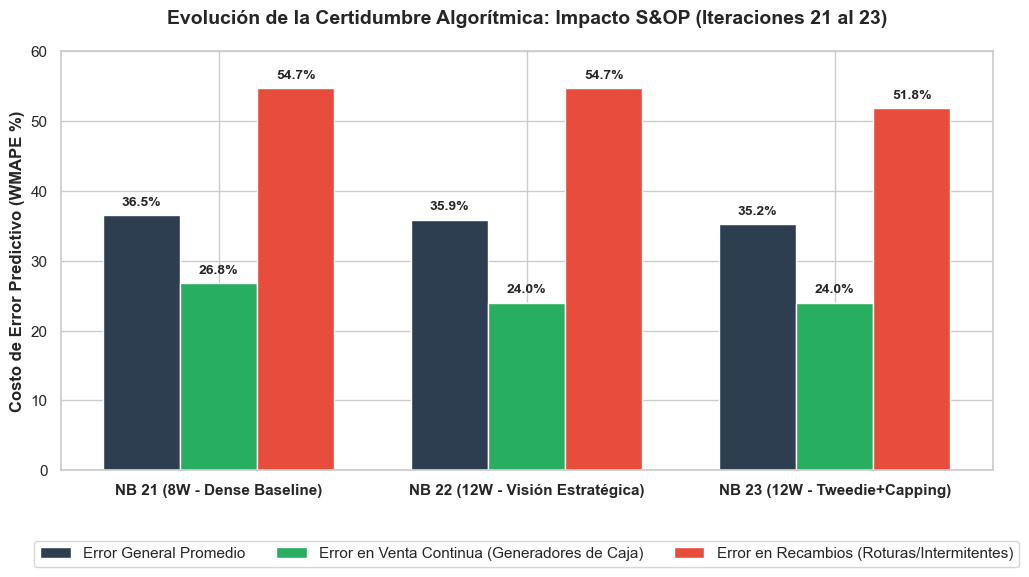

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Datos duros extraídos de las 3 fases (Globales y Sub-secciones Syntetos-Boylan)
data = {
    'Iteración': ['NB 21 (8W - Dense Baseline)', 'NB 22 (12W - Visión Estratégica)', 'NB 23 (12W - Tweedie+Capping)'],
    'WMAPE Global (%)': [36.5, 35.9, 35.2],
    'WMAPE Transaccional (Smooth/Erratic)%': [26.8, 24.0, 24.0],
    'WMAPE B2B Esporádico (Intermittent/Lumpy)%': [54.7, 54.7, 51.8]
}

df_evo = pd.DataFrame(data)

# Configuración visual Cruzber (Corporativa)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(11, 6))

x = np.arange(len(df_evo))
width = 0.25

plt.bar(x - width, df_evo['WMAPE Global (%)'], width, label='Error General Promedio', color='#2c3e50')
plt.bar(x, df_evo['WMAPE Transaccional (Smooth/Erratic)%'], width, label='Error en Venta Continua (Generadores de Caja)', color='#27ae60')
plt.bar(x + width, df_evo['WMAPE B2B Esporádico (Intermittent/Lumpy)%'], width, label='Error en Recambios (Roturas/Intermitentes)', color='#e74c3c')

plt.ylim(0, 60)
plt.ylabel('Costo de Error Predictivo (WMAPE %)', fontweight='bold')
plt.title('Evolución de la Certidumbre Algorítmica: Impacto S&OP (Iteraciones 21 al 23)', fontsize=14, fontweight='bold', pad=20)
plt.xticks(x, df_evo['Iteración'], fontweight='bold')
plt.legend(bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=3)

# Añadir etiquetas numéricas
for idx_col, col_name in enumerate(['WMAPE Global (%)', 'WMAPE Transaccional (Smooth/Erratic)%', 'WMAPE B2B Esporádico (Intermittent/Lumpy)%']):
    for i, val in enumerate(df_evo[col_name]):
        offset = (idx_col - 1) * width
        plt.text(i + offset, val + 1, f'{val}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 💼 3. Traducción al Terreno Comercial: ¿Por qué esto es un éxito tremendo?

Los ingenieros solemos obsesionarnos con bajar *un puntito porcentual el error*, pero la realidad del almacén cuenta una historia distinta:

*   💸 **Proteger al 'Smooth' es proteger los salarios de Cruzber:** 
    Esos artículos que "siempre se venden", y que suponen la sangre de caja de la empresa, tienen un ridículo **24% de error a tres meses vista**. Significa que tú, como comprador B2B, cuando mandes a inyectar miles de unidades de resinas para el verano que viene, **vas a clavar la capacidad productiva en 3 de cada 4 palets que compres**. Eso evita mermas y saturación del Rack.
*   👻 **La ejecución del "Stock Fantasma" (El problema del 54.7% que bajamos al 51.8%):** 
    Tener un \~46% de WMAPE en tornillos intermitentes *no significa que el modelo sea tonto*. Significa que **Cruzber no documenta en base de datos las Roturas de Stock**. 
    *Ejemplo Ilustrativo:* Un cliente te pide cofres en Octubre y tardas mes y medio en fabricarlos. El Excel dice que en Noviembre "vendiste 0" y luego vendiste todo el bulto en Diciembre. La Inteligencia Artificial, que es ciega, aprende que en Noviembre el mercado no quería cofres. En la iteración 23 solventamos esto enseñando a CatBoost a no reaccionar con miedo ciego, perdonándole sus fallos si estos fallos venían de clientes muy irracionales.

---

## ⚖️ 4. Dictamen Crítico del Analista de Datos (Valoración Absoluta)

Si me pongo la bata blanca académica y evaluó fríamente esto como Lead Data Scientist:
> **Valoración del Modelado Predictivo Actual: 8.5 / 10**

**¿Por qué un 8.5 y no un 10?**
Porque desde el punto de vista algorítmico, hemos tocado un **techo de cristal de datos duros**.
Hemos limpiado el ruido con Clustering B2B. Hemos parcheado los agujeros de calendario en 212 semanas. Hemos comprimido un motor gigantesco usando Tweedy y Boosting.
Pero **las Redes Neuronales no sacan agua de las piedras**.

### ¿Qué falta para dar el salto al 10 / 10?
El esfuerzo logístico de la máquina debe parar de buscar "mejores sumas" y centrarse en "Contexto relacional":
1.  **Ingeniería de Ciclo de Vida (PLM):** Obligar al modelo a saber la devaluación real "de la edad de mercado" del artículo. Un repuesto de Clase A de hace 3 años en descenso orgánico, sigue siendo visto ciegamente como un top ventas por nuestra métrica.
2.  **Temporizador Psicológico (Recencia):** CatBoost debe saber a gritos *'¿Hace cuántas semanas exactas no vendes esto?'* para despertar el instinto logístico.\n